# Supervised Learning on Tabular Data: Domain Shift & Covariate Shift
### Overview
In this notebook, we evaluate traditional, widely used machine learning paradigms for supervised learning on tabular data under **Out-Of-Distribution (OOD)** scenarios. Before exploring complex deep learning architectures or domain adaptation algorithms, it is essential to establish strong, interpretable baselines and understand exactly *how* and *why* models fail when the environment changes.

While the broader field of "Domain Shift" includes various phenomena (Label Shift, Concept Drift, etc.), we will focus here on **Covariate Shift**. This occurs when the underlying biological relationship ($P(Y|X)$) remains identical, but the marginal distribution of the features ($P(X)$) changes due to sensor calibration, different hardware, or background noise (commonly known as **Batch Effects**).

We will systematically evaluate a linear baseline across two distinct domains simultaneously:
* **Standard Tabular Data (2D Example):** A classic 2D dataset to build geometric intuition on how Covariate Shift destroys linear decision boundaries.
* **Biological Data ($P \gg N$):** A high-dimensional oncology dataset characterized by extreme sparsity. This domain challenges algorithms to maintain robustness under high-dimensional feature interactions and distributional shifts.

**Terminology:**
* **$N$ (Number of Samples):** The number of data points (e.g., patients) in the dataset. 
* **$P$ (Number of Features):** The number of dimensions for each sample. While some dimensions contain the true informative signal, others are nuisance dimensions (noise) that challenge feature selection.

Weights (W1, W2): [[ 4.10519231 -5.72442044]]
Bias (b): [4.49531259]
Source Domain (ID) Accuracy:   0.95
Target Domain (OOD) Accuracy:  0.71


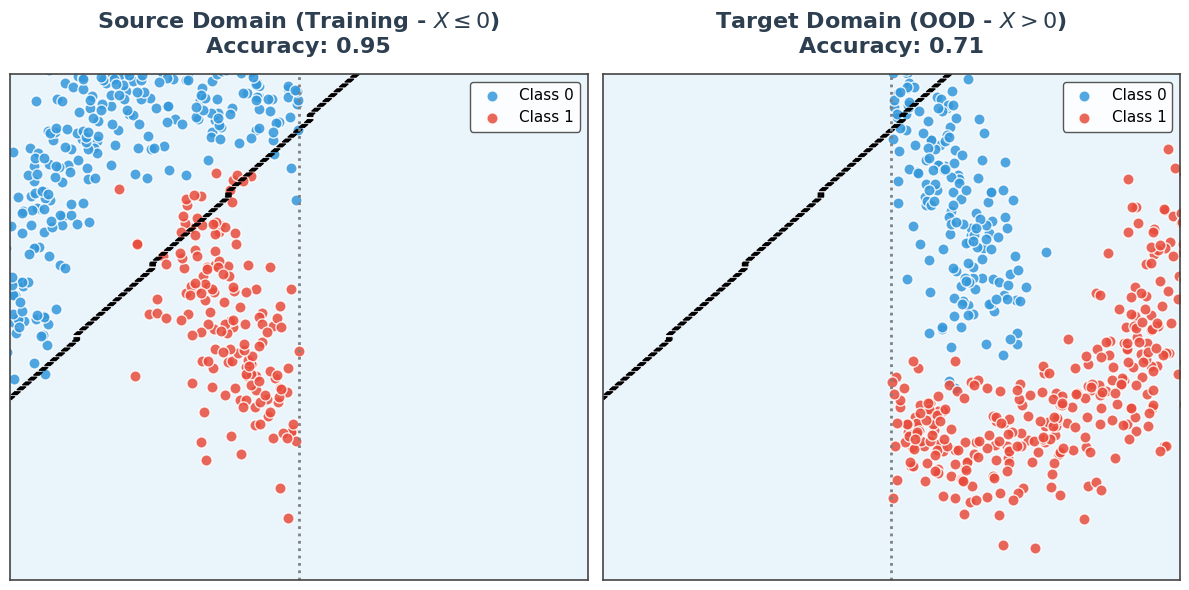

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ==========================================
# 1. Base Data Generation (Two Moons)
# ==========================================
# Generate 1000 samples with noise to make it realistic (~80% accuracy for linear model)
X_base, y_base = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Shift X so the center of the dataset is exactly at X = 0 (as Ofir requested)
X_base[:, 0] = X_base[:, 0] - 0.5 

# ==========================================
# 2. Split into Source (ID) and Target (OOD)
# ==========================================
# Source Domain: Left side (X <= 0)
source_mask = X_base[:, 0] <= 0
X_source, y_source = X_base[source_mask], y_base[source_mask]

# Target Domain: Right side (X > 0)
target_mask = X_base[:, 0] > 0
X_target, y_target = X_base[target_mask], y_base[target_mask]

# ==========================================
# 3. Test Logistic Regression Performance
# ==========================================
clf = LogisticRegression()
clf.fit(X_source, y_source)

# להדפיס את המשקלים של X ו-Y
print("Weights (W1, W2):", clf.coef_)

# להדפיס את ה-Bias
print("Bias (b):", clf.intercept_)

acc_source = accuracy_score(y_source, clf.predict(X_source))
acc_target = accuracy_score(y_target, clf.predict(X_target))

print(f"Source Domain (ID) Accuracy:   {acc_source:.2f}")
print(f"Target Domain (OOD) Accuracy:  {acc_target:.2f}")

# ==========================================
# 4. Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# Decision Boundary plotting function
def plot_boundary(ax, X, model):
    x_min, x_max = -1.5, 1.5
    y_min, y_max = -1.0, 1.0
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.1, colors=[color_blue, color_red])
    ax.contour(xx, yy, Z, colors='k', linewidths=1, linestyles='--')

# --- Plot Source Domain (S) ---
plot_boundary(ax1, X_source, clf)
ax1.scatter(X_source[y_source == 0][:, 0], X_source[y_source == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, label='Class 0')
ax1.scatter(X_source[y_source == 1][:, 0], X_source[y_source == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, label='Class 1')
ax1.set_title(f"Source Domain (Training - $X \leq 0$)\nAccuracy: {acc_source:.2f}", fontsize=16, fontweight='600', color='#2c3e50', pad=15)
ax1.axvline(x=0, color='gray', linestyle=':', linewidth=2) # Add the X=0 split line

# --- Plot Target Domain (T) ---
plot_boundary(ax2, X_target, clf)
ax2.scatter(X_target[y_target == 0][:, 0], X_target[y_target == 0][:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, label='Class 0')
ax2.scatter(X_target[y_target == 1][:, 0], X_target[y_target == 1][:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, label='Class 1')
ax2.set_title(f"Target Domain (OOD - $X > 0$)\nAccuracy: {acc_target:.2f}", fontsize=16, fontweight='600', color='#2c3e50', pad=15)
ax2.axvline(x=0, color='gray', linestyle=':', linewidth=2) # Add the X=0 split line

# --- Clean Aesthetic Formatting & Legends ---
for ax in [ax1, ax2]:
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.0, 1.0)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#444444')
        spine.set_linewidth(1.2)
        
    ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='#444444', facecolor='white', framealpha=0.9)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Set seed for reproducibility
np.random.seed(42)

# ==========================================
# 1. Base Data Generation
# ==========================================
X_base, y_base = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

X_base = StandardScaler().fit_transform(X_base)
X_blue_base = X_base[y_base == 0]
X_red_base = X_base[y_base == 1]

# ==========================================
# 2. Source Domain (S) Construction
# ==========================================
X_blue_s = X_blue_base * 0.35 + [0.0, 1.4]

x_min, x_max = X_red_base[:, 0].min(), X_red_base[:, 0].max() 
x_red_s = -1.5 + (X_red_base[:, 0] - x_min) / (x_max - x_min) * 4.5
y_red_s_curve = 1.6 * (1 - np.exp(-(x_red_s + 1.5))) - 0.9
y_red_s = y_red_s_curve + X_red_base[:, 1] * 0.15
X_red_s = np.column_stack([x_red_s, y_red_s])

# ==========================================
# 3. Target Domain (T) Construction
# ==========================================
center_x, center_y = 0.5, 0.6
X_blue_t = X_blue_base * 0.20 + [center_x, center_y - 0.1]

theta_red = -np.pi + (X_red_base[:, 0] - x_min) / (x_max - x_min) * np.pi
r_red = 0.9 + X_red_base[:, 1] * 0.15 
X_red_t = np.column_stack([
    r_red * np.cos(theta_red) + center_x, 
    r_red * np.sin(theta_red) + center_y + 0.2
])

Let's visualize the 2D geometric transformation. In the **Source Domain ($\mathcal{S}$)**, notice the clear linear margin separating the two classes. In the **Target Domain ($\mathcal{T}$)**, the data has undergone a non-linear Covariate Shift (while preserving the original labels), causing the classes to physically overlap from the perspective of a linear hyperplane.

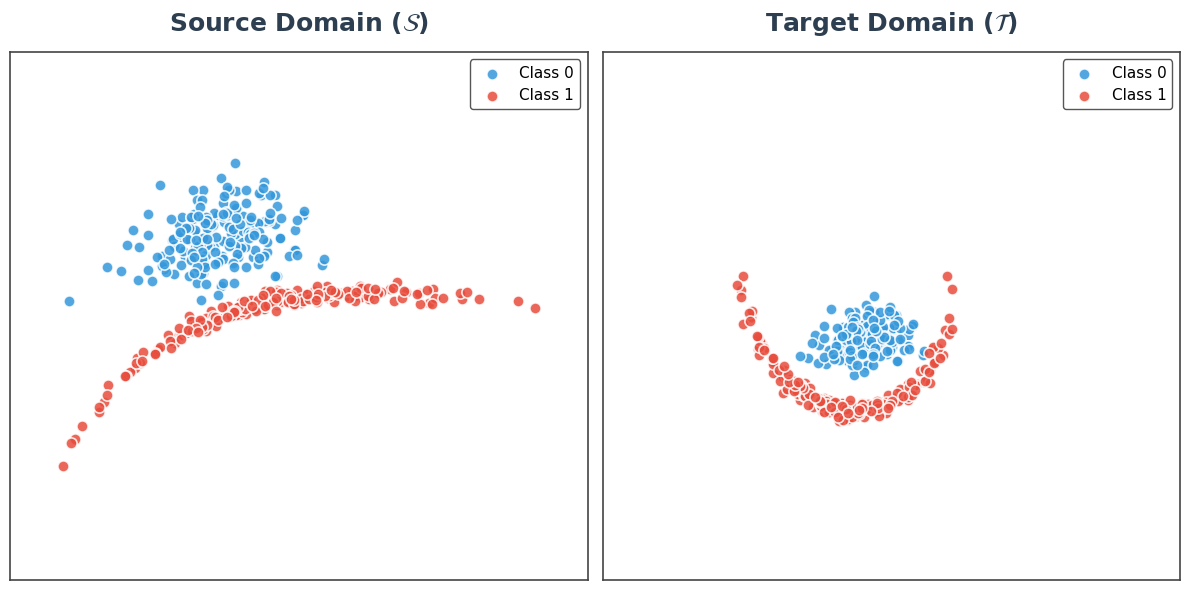

In [ ]:
# ==========================================
# Visualization
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

color_blue = '#3498db'
color_red = '#e74c3c'

# --- Plot Source Domain (S) ---
ax1.scatter(X_blue_s[:, 0], X_blue_s[:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, linewidth=1.2, label='Class 0')
ax1.scatter(X_red_s[:, 0], X_red_s[:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, linewidth=1.2, label='Class 1')
ax1.set_title("Source Domain ($\mathcal{S}$)", fontsize=18, fontweight='600', color='#2c3e50', pad=15)

# --- Plot Target Domain (T) ---
ax2.scatter(X_blue_t[:, 0], X_blue_t[:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, linewidth=1.2, label='Class 0')
ax2.scatter(X_red_t[:, 0], X_red_t[:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, linewidth=1.2, label='Class 1')
ax2.set_title("Target Domain ($\mathcal{T}$)", fontsize=18, fontweight='600', color='#2c3e50', pad=15)

# --- Clean Aesthetic Formatting & Legends ---
for ax in [ax1, ax2]:
    ax.set_xlim(-2.0, 3.5)
    ax.set_ylim(-1.5, 2.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color('#444444')
        spine.set_linewidth(1.2)
        
    # Add Legend
    ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='#444444', facecolor='white', framealpha=0.9)

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

### Transitioning to Biological Reality ($P \gg N$)

While the 2D example provides excellent geometric intuition, clinical and biological datasets (e.g., RNA sequencing, proteomics) exist in thousands of dimensions. 

*Note on Visualization:* We intentionally skip applying Principal Component Analysis (PCA) to visualize this high-dimensional shift. In a space of 2,000 features where 1,950 are noise, PCA may emphasize nuisance variance rather than label-relevant structure, so it can obscure the shift instead of clarifying it. rather than the underlying biological signal. Plotting this would result in an uninformative "hairball" that masks both the biology and the domain shift. Instead, we will directly rely on algorithmic evaluation to measure the impact.

Below, we simulate a biologically inspired high-dimensional environment and induce a structured covariance shift by applying a dense mixing matrix with a low-rank perturbation (U · V), we introduce structured changes to the covariance structure of the feature space, mimicking a severe laboratory batch effect.

In [ ]:
# ---------------------------------------------------------
# 1. Generate the Biological Data (P >> N)
# ---------------------------------------------------------
P_FEATURES = 2000
N_SAMPLES = 400

# Source Domain (S): Clean Biological Measurements
X_bio_s, y_bio_s = make_classification(
    n_samples=N_SAMPLES, n_features=P_FEATURES, n_informative=50, 
    n_redundant=0, random_state=42
)

# Target Domain (T): Classic Batch Effect (Covariate Shift)
np.random.seed(100)
P = P_FEATURES
N = N_SAMPLES

# --- Create a full covariance mixing matrix ---
A = np.random.normal(0, 0.05, size=(P, P))

# make it "near identity but corrupted"
A = A + np.eye(P)

# optional: low-rank distortion (important!)
U = np.random.normal(0, 0.1, size=(P, 10))
V = np.random.normal(0, 0.1, size=(10, P))
A += U @ V   # induces structured correlation shift

# --- noise (important for degradation) ---
noise = np.random.normal(0, 0.5, size=X_bio_s.shape)

# --- Target domain ---
X_bio_t = X_bio_s @ A + noise

# labels unchanged
y_bio_t = y_bio_s

# ---------------------------------------------------------
# 2. Linear Model Robustness Evaluation
# ---------------------------------------------------------

# --- Prepare 2D Standard Data Arrays (from Part 1) ---
X_S_2D = np.vstack([X_blue_s, X_red_s])
y_S_2D = np.hstack([np.zeros(len(X_blue_s)), np.ones(len(X_red_s))])
X_T_2D = np.vstack([X_blue_t, X_red_t])
y_T_2D = np.hstack([np.zeros(len(X_blue_t)), np.ones(len(X_red_t))])

In [10]:
# --- Train & Evaluate Models (Trained strictly on Source S) ---

# Model 1: Standard Data Model (2D)
clf_2d = LogisticRegression(random_state=42)
clf_2d.fit(X_S_2D, y_S_2D)
acc_s_2d = accuracy_score(y_S_2D, clf_2d.predict(X_S_2D))
acc_t_2d = accuracy_score(y_T_2D, clf_2d.predict(X_T_2D))

# Model 2: Biological Data Model (5000D)
# L2 Regularization is applied by default, dispersing weights across all 5000 channels
clf_bio = LogisticRegression(random_state=42, max_iter=1000)
clf_bio.fit(X_bio_s, y_bio_s)
acc_s_bio = accuracy_score(y_bio_s, clf_bio.predict(X_bio_s))
acc_t_bio = accuracy_score(y_bio_t, clf_bio.predict(X_bio_t))

# ---------------------------------------------------------
# 3. Print Final Benchmark Report
# ---------------------------------------------------------
print("=" * 60)
print("LINEAR MODEL ROBUSTNESS REPORT (Logistic Regression)")
print("=" * 60)

print("\n[1] STANDARD DATA (2D TOY EXAMPLE):")
print("-" * 45)
print(f"Accuracy on Source Domain (S): {acc_s_2d * 100:.1f}%")
print(f"Accuracy on Target Domain (T): {acc_t_2d * 100:.1f}%")

print("\n[2] BIOLOGICAL DATA (5000D):")
print("-" * 45)
print(f"Accuracy on Source Domain (S): {acc_s_bio * 100:.1f}%")
print(f"Accuracy on Target Domain (T): {acc_t_bio * 100:.1f}%")
print("=" * 60)

LINEAR MODEL ROBUSTNESS REPORT (Logistic Regression)

[1] STANDARD DATA (2D TOY EXAMPLE):
---------------------------------------------
Accuracy on Source Domain (S): 98.2%
Accuracy on Target Domain (T): 49.0%

[2] BIOLOGICAL DATA (5000D):
---------------------------------------------
Accuracy on Source Domain (S): 100.0%
Accuracy on Target Domain (T): 81.0%


### Analysis of the Results & The Need for Domain Adaptation

The benchmark report reveals an important insight into how linear models behave under different manifestations of Covariate Shift:

1. **The 2D Geometric Crash (49%):** In a low-dimensional space, the linear model has nowhere to hide. When the geometry shifts from separable clusters into a U-shaped envelope, the learned linear decision boundary no longer aligns with the data distribution and effectively cuts through both classes, reducing accuracy to nearly random guessing.

2. **The 2000D Degradation (81%):** The high-dimensional model does not collapse completely despite the induced covariance shift. Although the model retains part of the signal due to redundant feature structure and L2 regularization, its performance still drops substantially under the shifted covariance structure. The structured feature mixing alters cross-feature dependencies and partially disrupts the relationships learned in the Source domain. While the model remains functional, a reduction from 100% to 81% accuracy would still represent a severe failure in a high-stakes clinical setting.

**Key Observation:** The two experiments illustrate different manifestations of Covariate Shift. The 2D example demonstrates a severe geometric distortion that directly breaks the learned linear boundary, whereas the 2000D experiment demonstrates a structured covariance shift that degrades performance by altering feature correlations. In both cases, the model is evaluated on data generated from a distribution different from the one on which it was trained.

**Next Steps:** Since traditional supervised learning algorithms are inherently unaware of distributional mismatch between domains, we now require explicit Domain Adaptation techniques. In the following sections, we introduce **CORAL (Correlation Alignment)**, which attempts to realign the covariance structure of the Target domain with that of the Source domain before classification.


# Unsupervised Domain Adaptation: CORAL (Correlation Alignment)

When models fail due to Covariate Shift, we cannot simply retrain them on the Target domain, as we typically lack labeled data in the new environment (e.g., a new hospital cannot wait to label thousands of new patients before using the model). 

Instead, we use **Unsupervised Domain Adaptation (UDA)**. A classic and highly effective algorithm for this is **CORAL (Correlation Alignment)**.
CORAL operates by computing the second-order statistics (covariance) of both the Source and Target features, and then applying a linear transformation to the Source data so its covariance perfectly matches the Target. 

**The CORAL Transformation Steps:**
1. **Whiten the Source:** Remove existing correlations in the Source domain.
2. **Re-color with Target:** Project the Target domain's covariance structure onto the whitened Source data.

Let's implement CORAL and evaluate it on both our 2D Toy Example and our 2000D Biological Data.

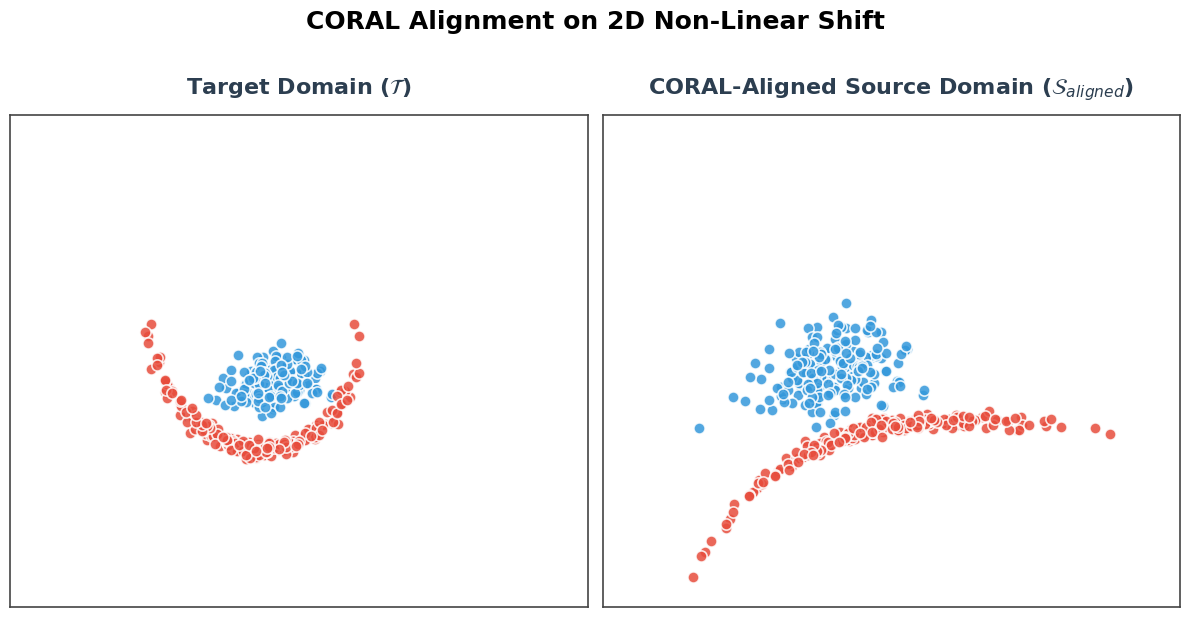

In [11]:
from scipy.linalg import fractional_matrix_power

# ==========================================
# 1. The CORAL Algorithm Implementation
# ==========================================
def coral_alignment(X_source, X_target, lambda_reg=1.0):
    """
    Aligns the covariance structure of the Source domain to the Target domain.
    lambda_reg: Regularization parameter to ensure covariance matrices are invertible (vital for P >> N).
    """
    d = X_source.shape[1]
    
    # Calculate regularized covariance matrices
    Cs = np.cov(X_source, rowvar=False) + np.eye(d) * lambda_reg
    Ct = np.cov(X_target, rowvar=False) + np.eye(d) * lambda_reg
    
    # Calculate fractional matrix powers
    Cs_inv_sqrt = fractional_matrix_power(Cs, -0.5)
    Ct_sqrt = fractional_matrix_power(Ct, 0.5)
    
    # Align Source to Target: Center -> Whiten -> Recolor -> Recenter
    X_s_centered = X_source - np.mean(X_source, axis=0)
    X_s_aligned = X_s_centered @ Cs_inv_sqrt @ Ct_sqrt + np.mean(X_target, axis=0)
    
    return np.real(X_s_aligned) # Ensure strictly real numbers


# ==========================================
# 2. Applying CORAL to the 2D Standard Data
# ==========================================
# Combine the individual classes into full domain arrays
X_S_2D = np.vstack([X_blue_s, X_red_s])
y_S_2D = np.hstack([np.zeros(len(X_blue_s)), np.ones(len(X_red_s))])
X_T_2D = np.vstack([X_blue_t, X_red_t])
y_T_2D = np.hstack([np.zeros(len(X_blue_t)), np.ones(len(X_red_t))])

# Apply CORAL to align the 2D Source to the 2D Target
X_S_2D_coral = coral_alignment(X_S_2D, X_T_2D)

# Separate back for visualization
X_blue_s_coral = X_S_2D_coral[y_S_2D == 0]
X_red_s_coral = X_S_2D_coral[y_S_2D == 1]

# Visualization of the Aligned 2D Space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot Original Target Domain (The Goal)
ax1.scatter(X_blue_t[:, 0], X_blue_t[:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, linewidth=1.2)
ax1.scatter(X_red_t[:, 0], X_red_t[:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, linewidth=1.2)
ax1.set_title("Target Domain ($\mathcal{T}$)", fontsize=16, fontweight='600', color='#2c3e50', pad=15)

# Plot CORAL Aligned Source Domain
ax2.scatter(X_blue_s_coral[:, 0], X_blue_s_coral[:, 1], c=color_blue, alpha=0.85, edgecolors='white', s=65, linewidth=1.2)
ax2.scatter(X_red_s_coral[:, 0], X_red_s_coral[:, 1], c=color_red, alpha=0.85, edgecolors='white', s=65, linewidth=1.2)
ax2.set_title("CORAL-Aligned Source Domain ($\mathcal{S}_{aligned}$)", fontsize=16, fontweight='600', color='#2c3e50', pad=15)

for ax in [ax1, ax2]:
    ax.set_xlim(-2.0, 3.5); ax.set_ylim(-1.5, 2.5)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color('#444444'); spine.set_linewidth(1.2)

fig.patch.set_facecolor('white')
plt.suptitle("CORAL Alignment on 2D Non-Linear Shift", fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Notice the visualization above: The Target domain features a severe **non-linear** shift (a U-shape enveloping a dense cluster). Because CORAL is a **linear** alignment algorithm (matching means and covariance matrices), it scales and rotates the Source data perfectly, but it *cannot* bend the data into a U-shape. We expect the linear model to still struggle here.

However, in our **2000D Biological Data**, the Batch Effect was generated via an affine transformation (mixing matrix + noise). This is exactly the mathematical scenario CORAL was built to solve. Let's apply CORAL to the high-dimensional data and benchmark the results.

In [12]:
# ==========================================
# 3. Applying CORAL to 2000D Biological Data
# ==========================================
# Align the high-dimensional source data to the target data
# We use lambda_reg=1.0 to handle the P >> N covariance singularity
X_bio_s_coral = coral_alignment(X_bio_s, X_bio_t, lambda_reg=1.0)


# ==========================================
# 4. Final Robustness Evaluation (With CORAL)
# ==========================================

# --- Evaluate on 2D Standard Data ---
clf_2d_coral = LogisticRegression(random_state=42)
clf_2d_coral.fit(X_S_2D_coral, y_S_2D) # Train on ALIGNED Source
acc_s_2d_coral = accuracy_score(y_S_2D, clf_2d_coral.predict(X_S_2D_coral))
acc_t_2d_coral = accuracy_score(y_T_2D, clf_2d_coral.predict(X_T_2D)) # Test on Target

# --- Evaluate on 2000D Biological Data ---
clf_bio_coral = LogisticRegression(random_state=42, max_iter=1000)
clf_bio_coral.fit(X_bio_s_coral, y_bio_s) # Train on ALIGNED Source
acc_s_bio_coral = accuracy_score(y_bio_s, clf_bio_coral.predict(X_bio_s_coral))
acc_t_bio_coral = accuracy_score(y_bio_t, clf_bio_coral.predict(X_bio_t)) # Test on Target

# ==========================================
# Print Final Domain Adaptation Report
# ==========================================
print("=" * 70)
print("DOMAIN ADAPTATION REPORT: CORAL (Correlation Alignment)")
print("=" * 70)

print("\n[1] STANDARD DATA (2D TOY EXAMPLE):")
print("-" * 55)
print(f"BASELINE Target Accuracy:      {acc_t_2d * 100:.1f}%")
print(f"CORAL Target Accuracy:         {acc_t_2d_coral * 100:.1f}%")

print("\n[2] BIOLOGICAL DATA (2000D):")
print("-" * 55)
print(f"BASELINE Target Accuracy:      {acc_t_bio * 100:.1f}%")
print(f"CORAL Target Accuracy:         {acc_t_bio_coral * 100:.1f}%")
print("=" * 70)

DOMAIN ADAPTATION REPORT: CORAL (Correlation Alignment)

[1] STANDARD DATA (2D TOY EXAMPLE):
-------------------------------------------------------
BASELINE Target Accuracy:      49.0%
CORAL Target Accuracy:         84.2%

[2] BIOLOGICAL DATA (2000D):
-------------------------------------------------------
BASELINE Target Accuracy:      81.0%
CORAL Target Accuracy:         86.2%


### Conclusion: The Architecture of Robustness and its Limits

The empirical results from our CORAL benchmark reveal a fascinating and highly nuanced reality about Domain Adaptation algorithms:

1. **The 2D Partial Recovery (49.0% $\rightarrow$ 84.2%):** While CORAL significantly improved the 2D accuracy, it failed to recover the original 98.2%. Because CORAL is strictly a *linear* affine transformation (scaling, translating, and rotating), it successfully moved the Source data into the correct general coordinate space of the Target. However, it fundamentally cannot bend the data to match the non-linear "U-shape" topology of the Target domain, leaving a permanent classification error gap.

2. **The High-Dimensional Covariance Trap (81.0% $\rightarrow$ 86.2%):** In the 2000D environment, the distortion was linear (a mixing matrix), which theoretically is CORAL's perfect use-case. Yet, it only recovered 5%. Why? **Sample Complexity in the $P \gg N$ regime.** CORAL relies on estimating the empirical covariance matrix. In our data, we attempted to estimate a $2000 \times 2000$ matrix using only $N=400$ samples. The resulting empirical covariance matrix is highly rank-deficient and noisy. Consequently, CORAL applied a flawed, noisy alignment. 

**Final Takeaway:** This notebook proves that standard Domain Adaptation tools like CORAL are mathematically limited by two factors: **Non-linear shifts** (in low dimensions) and **Covariance estimation errors** (in high dimensions with sparse samples). To solve these real-world biological challenges, the field must look toward Deep Domain Adaptation or constrained regularization techniques.